In [4]:
from __future__ import annotations
from dataclasses import dataclass
from typing import Any, Dict, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, accuracy_score

import tensorflow as tf
import optuna

# Reproducibility
RANDOM_STATE: int = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

In [5]:
from pathlib import Path

def load_housing (path):
    p=Path(path)
    if not p.exists():
         raise  FileNotFoundError (f"file not found")
    
    return pd.read_csv(p)
df=load_housing('train_Kaggle.csv')
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 2) Exploratory Data Analysis (EDA)


Shape: (1460, 76)

Missing rate (top 15):
FireplaceQu     0.472603
LotFrontage     0.177397
GarageYrBlt     0.055479
GarageQual      0.055479
GarageFinish    0.055479
GarageType      0.055479
GarageCond      0.055479
BsmtFinType2    0.026027
BsmtExposure    0.026027
BsmtQual        0.025342
BsmtCond        0.025342
BsmtFinType1    0.025342
MasVnrArea      0.005479
Electrical      0.000685
LotConfig       0.000000
dtype: float64


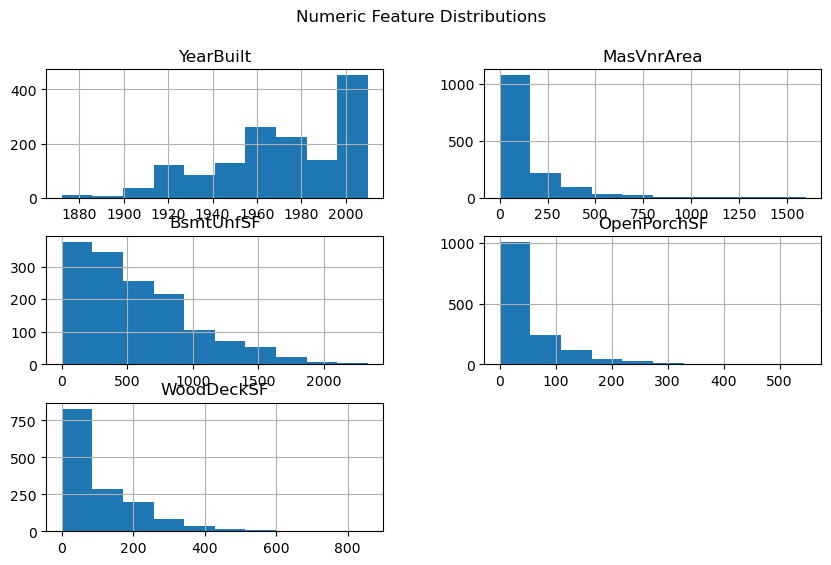


 Price by Kitchen Quality:
KitchenQual
Ex    328554.67
Gd    212116.02
TA    139962.51
Fa    105565.21
Name: SalePrice, dtype: float64

Price rate by BsmtQual:
BsmtQual
Ex    327041.04
Gd    202688.48
TA    140759.82
Fa    115692.03
Name: SalePrice, dtype: float64
new shape of df: (1460, 76)


In [ ]:
# %% [code]
def eda_overview(df: pd.DataFrame, target_col: str) -> None:
    """Print basic dataset diagnostics and show a few key plots."""
    print("Shape:", df.shape)
    print("\nMissing rate (top 15):")
    print(df.isna().mean().sort_values(ascending=False).head(15))

    # Numeric distributions (only those present)
    #find columns with numerical values
    numeric_cols = [c for c in ["YearBuilt", "MasVnrArea", "BsmtUnfSF", "OpenPorchSF", "WoodDeckSF"] if c in df.columns]
    if numeric_cols:
        df[numeric_cols].hist(bins=10, figsize=(10, 6))
        plt.suptitle("Numeric Feature Distributions")
        plt.show()
    return


eda_overview(df, target_col="SalePrice")

# Simple group stats (if columns exist)
if "KitchenQual" in df.columns:
    print("\n Price by Kitchen Quality:")
    print(df.groupby("KitchenQual")["SalePrice"].mean().sort_values(ascending=False).round(2))

if "BsmtQual" in df.columns:
    print("\nPrice rate by BsmtQual:")
    print(df.groupby("BsmtQual")["SalePrice"].mean().sort_values(ascending=False).round(2))

# remove columns with too many missing values
for col in df.columns:
    if df[col].isna().mean() > 0.5:
        print(f"Dropping {col}")
        df.drop(columns=[col], inplace=True)

print("new shape of df:", df.shape)

## 3) Feature engineering (including interaction features)

We create:

- `YardSQ = WoodDeckSF+ OpenPorchSF + 1`
- `Title` from `Name`

Then we add **interaction features** via `PolynomialFeatures` (degree tuned with Optuna).


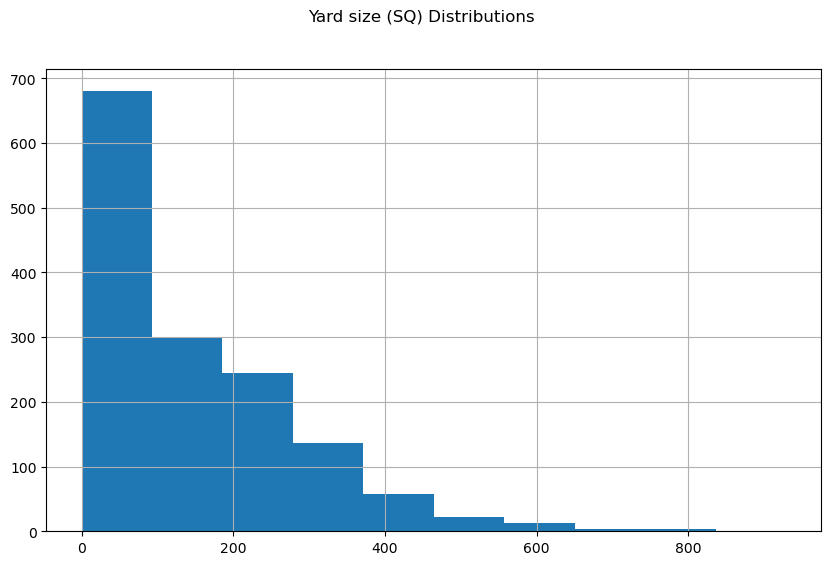

In [22]:
def add_engineered_features(df: pd.DataFrame) -> pd.DataFrame:
    """Add engineered features to the Titanic dataset.

    Args:
        df: Housing.

    Returns:
        Copy of df with additional engineered columns.
    """
    out = df.copy()
    if set(["OpenPorchSF", "WoodDeckSF"]).issubset(out.columns):
        out["YardSQ"] = out["OpenPorchSF"] + out["WoodDeckSF"] 
    else:
        out["YardSQ"] = 0
    return out
df_fe = add_engineered_features(df)

df_fe['YardSQ'].hist(bins=10, figsize=(10, 6))
plt.suptitle("Yard size (SQ) Distributions")
plt.show()


In [34]:
#remove missing values in each numerical column
num_cols = df_fe.select_dtypes(include=["int", "float"]).columns
for num_col in num_cols:
    df_fe[num_col].fillna(df_fe[num_col].mean(), inplace=True)
#remove missing values in each categorical column
cat_cols = df_fe.select_dtypes(include=["object"]).columns
for cat_col in cat_cols:
    df_fe[cat_col].fillna(df_fe[cat_col].mode()[0], inplace=True)
#print missing values
print(df_fe.isnull().sum())    

Id               0
MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
                ..
YrSold           0
SaleType         0
SaleCondition    0
SalePrice        0
YardSQ           0
Length: 77, dtype: int64


C:\Users\pc\AppData\Local\Temp\ipykernel_67556\2150647972.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_fe[num_col].fillna(df_fe[num_col].mean(), inplace=True)
C:\Users\pc\AppData\Local\Temp\ipykernel_67556\2150647972.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For

In [35]:
class HousingColumns():
    """Column configuration for the data modeling pipeline."""
    target: str = "SalePrice"
    cat_cols: Tuple[str, ...] = df_fe.select_dtypes(include=["object"]).columns
    num_cols: Tuple[str, ...] = df_fe.select_dtypes(include=["int", "float"]).columns

cfg = HousingColumns()
cat_cols = cfg.cat_cols
num_cols = cfg.num_cols
print(cat_cols)
print(num_cols)


X = df_fe.drop(columns=[cfg.target,'Id'])
y = df_fe[cfg.target].astype(int).values

print(X.shape)
print(y.shape)

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE)

Index(['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional',
       'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
       'PavedDrive', 'SaleType', 'SaleCondition'],
      dtype='object')
Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageYrBl

## 5) Keras model + Optuna hyperparameter optimization


In [36]:
def make_preprocessor(cat_cols: list[str], num_cols: list[str], poly_degree: int) -> ColumnTransformer:
    """Create a ColumnTransformer that imputes, expands interactions, scales, and one-hot encodes."""
    numeric_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("poly", PolynomialFeatures(degree=poly_degree, include_bias=False)),
        ("scaler", StandardScaler()),
    ])
    categorical_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])
    return ColumnTransformer([
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols),
    ])

# %% [code]
def build_classifier(input_dim: int, n_layers: int, units: int, dropout: float, l2: float, lr: float) -> tf.keras.Model:
    """Build a simple MLP binary classifier in Keras.

    Args:
        input_dim: Number of input features.
        n_layers: Number of hidden layers.
        units: Units per hidden layer.
        dropout: Dropout rate.
        l2: L2 regularization strength.
        lr: Learning rate.

    Returns:
        Compiled Keras model.
    """
    inputs = tf.keras.Input(shape=(input_dim,))
    x = inputs
    for _ in range(n_layers):
        x = tf.keras.layers.Dense(
            units,
            activation="relu",
            kernel_regularizer=tf.keras.regularizers.l2(l2),
        )(x)
        x = tf.keras.layers.Dropout(dropout)(x)

    outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)
    model = tf.keras.Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=[tf.keras.metrics.AUC(name="auc"), "accuracy"],
    )
    return model

def to_dense(x: Any) -> np.ndarray:
    """Convert scipy sparse matrix to dense numpy array if needed."""
    return x.toarray() if hasattr(x, "toarray") else np.asarray(x)

def optuna_objective(trial: optuna.Trial) -> float:
    """Optuna objective maximizing validation AUC."""
    poly_degree = trial.suggest_int("poly_degree", 1, 2)
    n_layers = trial.suggest_int("n_layers", 1, 4)
    units = trial.suggest_int("units", 32, 256, step=32)
    dropout = trial.suggest_float("dropout", 0.0, 0.5)
    l2 = trial.suggest_float("l2", 1e-8, 1e-3, log=True)
    lr = trial.suggest_float("lr", 1e-4, 3e-3, log=True)
    batch_size = trial.suggest_categorical("batch_size", [32, 64, 128])

    pre = make_preprocessor(cat_cols, num_cols, poly_degree)
    Xtr = to_dense(pre.fit_transform(X_train))
    Xva = to_dense(pre.transform(X_valid))

    model = build_classifier(Xtr.shape[1], n_layers, units, dropout, l2, lr)

    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_auc", mode="max", patience=8, restore_best_weights=True
        )
    ]
    # Optional pruning if installed
    try:
        from optuna.integration import TFKerasPruningCallback
        callbacks.append(TFKerasPruningCallback(trial, "val_auc"))
    except Exception:
        pass

    hist = model.fit(
        Xtr, y_train,
        validation_data=(Xva, y_valid),
        epochs=60,
        batch_size=batch_size,
        verbose=0,
        callbacks=callbacks,
    )
    return float(max(hist.history["val_auc"]))


In [39]:
# %% [code]
study = optuna.create_study(direction="maximize")
study.optimize(optuna_objective, n_trials=40)

print("Best AUC:", study.best_value)
print("Best params:", study.best_params)

[I 2026-01-07 19:45:05,530] A new study created in memory with name: no-name-688429e1-c2fb-4c12-aa75-206bea9bd5e7
[W 2026-01-07 19:55:08,607] Trial 0 failed with parameters: {'poly_degree': 2, 'n_layers': 4, 'units': 256, 'dropout': 0.27825401441799774, 'l2': 5.383582589570402e-05, 'lr': 0.0016564461688420558, 'batch_size': 64} because of the following error: ValueError('A given column is not a column of the dataframe').
Traceback (most recent call last):
  File "c:\ProgramData\anaconda3\lib\site-packages\pandas\core\indexes\base.py", line 3812, in get_loc
    return self._engine.get_loc(casted_key)
  File "pandas/_libs/index.pyx", line 167, in pandas._libs.index.IndexEngine.get_loc
  File "pandas/_libs/index.pyx", line 196, in pandas._libs.index.IndexEngine.get_loc
  File "pandas/_libs/hashtable_class_helper.pxi", line 7088, in pandas._libs.hashtable.PyObjectHashTable.get_item
  File "pandas/_libs/hashtable_class_helper.pxi", line 7096, in pandas._libs.hashtable.PyObjectHashTable.get_

KeyboardInterrupt: 